# TASK #1: PROJECT OVERVIEW 


In [ ]:
!pip install tensorflow

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
import seaborn as sns
import pickle
import random
print(tf.__version__)

In [ ]:
with open("./Problem 1/train.p", mode='rb') as training_data:
    train = pickle.load(training_data)

with open("./Problem 1/valid.p", mode='rb') as validation_data:
    valid = pickle.load(validation_data)

with open("./Problem 1/test.p", mode='rb') as testing_data:
    test = pickle.load(testing_data)

In [ ]:
X_train, y_train = train['features'], train['labels']
X_validation, y_validation = valid['features'], valid['labels']
X_test, y_test = test['features'], test['labels']

In [ ]:
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_validation.shape, y_validation.shape)
print("Test set:", X_test.shape, y_test.shape)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes_to_show = 25
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.ravel()

for i in range(classes_to_show):
    index = np.random.randint(0, len(X_train))
    axes[i].imshow(X_train[index])
    axes[i].set_title(f"Class: {y_train[index]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_validation, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("Number of classes in training set:", len(unique_train))
print("Number of classes in validation set:", len(unique_val))
print("Number of classes in test set:", len(unique_test))

In [ ]:
plt.figure(figsize=(14,6))
plt.bar(unique_train, counts_train)
plt.title("Number of Training Images per Class")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
plt.figure(figsize=(14,6))
plt.bar(unique_val, counts_val)
plt.title("Number of Validation Images per Class")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.show()

plt.figure(figsize=(14,6))
plt.bar(unique_test, counts_test)
plt.title("Number of Test Images per Class")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
class_count_df = pd.DataFrame({
    'Class ID': unique_train,
    'Train Count': counts_train,
    'Validation Count': counts_val,
    'Test Count': counts_test
})

class_count_df.head(10)

In [ ]:
class_count_df

In [ ]:
X_train.shape

In [ ]:
y_train.shape

In [ ]:
y_train

# TASK #2: PERFROM IMAGES VISUALIZATION

In [ ]:
i = np.random.randint(1, len(X_train))
plt.imshow(X_train[i])
y_train[i]

In [ ]:
# Let's view more images in a grid format
# Define the dimensions of the plot grid 
W_grid = 5
L_grid = 5

# fig, axes = plt.subplots(L_grid, W_grid)
# subplot return the figure object and axes object
# we can use the axes object to plot specific figures at various locations

fig, axes = plt.subplots(L_grid, W_grid, figsize = (10,10))

axes = axes.ravel() # flaten the 15 x 15 matrix into 225 array

n_training = len(X_train) # get the length of the training dataset

# Select a random number from 0 to n_training
for i in np.arange(0, W_grid * L_grid): # create evenly spaces variables 

    # Select a random number
    index = np.random.randint(0, n_training)
    # read and display an image with the selected index    
    axes[i].imshow( X_train[index])
    axes[i].set_title(y_train[index], fontsize = 15)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

        

# TASK #3: CONVERT IMAGES TO GRAYSCALE AND PERFORM NORMALIZATION

In [ ]:
%pip install scikit-learn

In [ ]:
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train)

In [ ]:
X_train_gray = np.sum(X_train/3, axis = 3, keepdims = True)
X_test_gray = np.sum(X_test/3, axis = 3, keepdims = True)
X_validation_gray = np.sum(X_validation/3, axis = 3, keepdims = True)

In [ ]:
X_train_gray.shape


In [ ]:
X_test_gray.shape


In [ ]:
X_train_gray_norm = (X_train_gray - 128)/128
X_test_gray_norm = (X_test_gray - 128)/128
X_validation_gray_norm = (X_validation_gray - 128)/128

In [ ]:
X_train_gray_norm

In [ ]:
i = random.randint(1, len(X_train_gray))
plt.imshow(X_train_gray[i].squeeze(), cmap = 'gray')
plt.figure()
plt.imshow(X_train[i])
plt.figure()
plt.imshow(X_train_gray_norm[i].squeeze(), cmap = 'gray')

# TASK #4: BUILD DEEP CONVOLUTIONAL NEURAL NETWORK MODEL

In [ ]:
from tensorflow.keras import datasets, layers, models

CNN_3 = models.Sequential()

CNN_3.add(layers.Conv2D(6, (5,5), activation='relu', input_shape=(32,32,1)))
CNN_3.add(layers.MaxPooling2D(pool_size=(2,2)))

CNN_3.add(layers.Conv2D(16, (5,5), activation='relu'))
CNN_3.add(layers.MaxPooling2D(pool_size=(2,2)))

CNN_3.add(layers.Flatten())
CNN_3.add(layers.Dense(120, activation='relu'))
CNN_3.add(layers.Dropout(0.5))
CNN_3.add(layers.Dense(84, activation='relu'))
CNN_3.add(layers.Dense(43, activation='softmax'))

CNN.summary()

# TASK #5: COMPILE AND TRAIN DEEP CNN MODEL

In [ ]:
CNN.compile(optimizer = 'Adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history = CNN.fit(X_train_gray_norm,
                 y_train, 
                 batch_size = 500,
                 epochs = 15,
                 verbose = 1,
                 validation_data = (X_validation_gray_norm, y_validation))

# TASK #6: ASSESS TRAINED CNN MODEL PERFORMANCE 

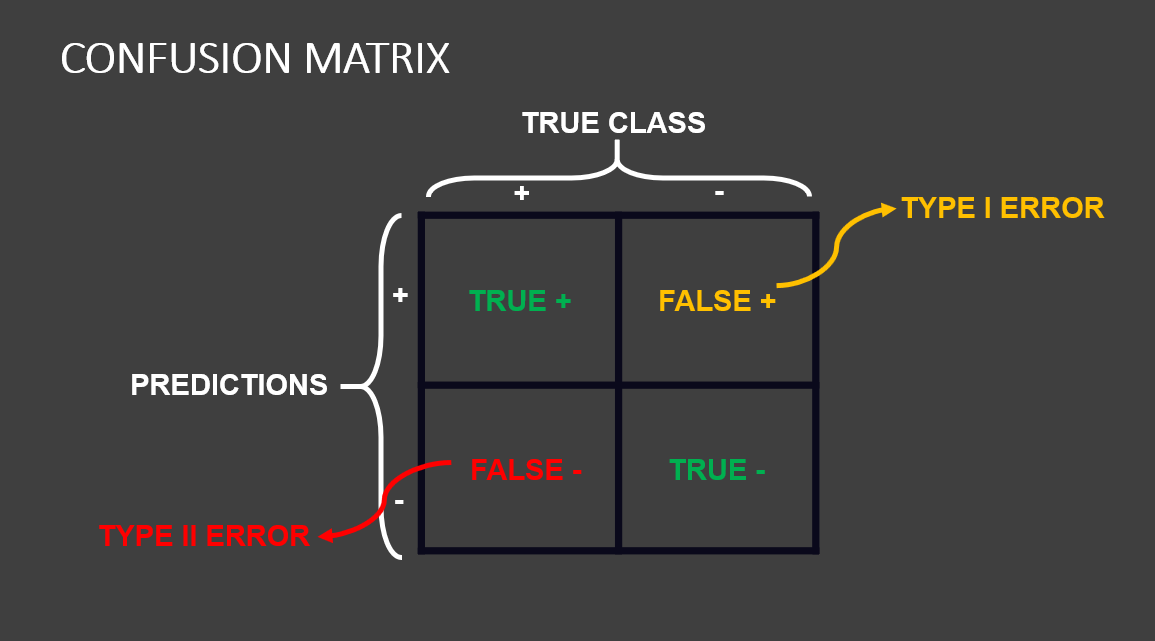

In [ ]:
score = CNN.evaluate(X_test_gray_norm, y_test)
print('Test Accuracy: {}'.format(score[1]))

In [ ]:
history.history.keys()

In [ ]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, 'bo', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

In [ ]:
plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

In [ ]:
model_C = models.Sequential([
    layers.Conv2D(16,(3,3),activation='relu',input_shape=(32,32,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(43,activation='softmax')
])

model_C.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_C = model_C.fit(
    X_train_gray_norm,y_train,
    epochs=15,
    batch_size=500,
    validation_data=(X_validation_gray_norm,y_validation),
    verbose=1
)

score_C = model_C.evaluate(X_test_gray_norm,y_test)

print("Model C Test Accuracy:",score_C[1])

In [ ]:
def plot_history(history, title):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(12,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title(title + ' Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title(title + ' Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

In [ ]:
plot_history(history_C,"Model C")

In [ ]:
plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

In [ ]:
# predicted_classes = CNN.predict_classes(X_test_gray_norm)

y_prob = CNN.predict(X_test_gray_norm)          # shape: (N, 43)
predicted_classes = np.argmax(y_prob, axis=1)   # shape: (N,)
y_true = y_test

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, predicted_classes)
plt.figure(figsize = (25, 25))
sns.heatmap(cm, fmt="d", annot = True);

In [ ]:
L = 5
W = 5

fig, axes = plt.subplots(L, W, figsize = (12, 12))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(X_test[i])
    axes[i].set_title('Prediction = {}\n True = {}'.format(predicted_classes[i], y_true[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace = 1)    

# GREAT JOB!